# Aprendizado por Reforço

---

**Professor:** Prof. Gabriel Lima  
**Aula:** 04  
**Exercício:** 4A  

---

### Objetivo :  
Implementar os algoritmos: 

- First Visit Monte Carlo Policy Evaluation
- TD(0) Policy Evaluation

## Bibliotecas Utilizadas

Para a implementação dos algoritmos utilizaremos as seguintes bibliotecas: 

In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import io

## Definição do Ambiente

Considere o seguinte ambiente a ser implementado: 

<img src="GridWorld.png" width="300"/>


- 𝒮 = {1, 2, 3, 4, 5, 6, 7}  
- 𝒮⁺ = {0, 8}  
- 𝒜 = {↑, →, ↓, ←}  

- ℛ(s, a) = −1 para qualquer ação tomada em um estado **não terminal**  
- ℛ(s, a) = 0 para qualquer ação tomada em um estado **terminal** (sombreado)  

- 𝒫 é **determinístico**, ou seja, 𝒫ₛₛ′ᵃ são matrizes binárias com ∑ₛ′ 𝒫ₛₛ′ᵃ = 1, ∀ s,a e o estado sucessor é o indicado pela ação (neste caso o agente não conhece).

- O agente permanece no mesmo estado caso tome ações que o levem para fora do grid, ou esteja em um estado terminal.

- 𝛾 = 0.9

In [2]:
class GridWorld:
    def __init__(self):
        self.size = 3
        self.gamma = 0.9

        self.grid = np.array([[0,1,1],
                              [1,1,1],
                              [1,1,0]])
        self.Frames   = []
        self.terminal = False
        self.positions= []
        self.action_space  = ['UP','DOWN','LEFT','RIGHT']
        self.state_space   = [(y,x) for y in range(self.size) for x in range(self.size)]

        # y linhas e x colunas

        # (y,x)
        self.state = None

    def initial_state(self):

      i = np.random.choice(np.arange(self.size))
      j = np.random.choice(np.arange(self.size))

      if self.grid[i][j] == 0:
        self.terminal = True
      else:
        self.terminal = False

      self.state = (i,j)
      self.Frames = []
      self.positions = [self.state]
      return self.state

    def step(self,action):

      y,x = self.state

      if action == 'UP' and y > 0 and not self.terminal:
          y -=1

      elif action == 'DOWN' and y < self.size-1 and not self.terminal:
          y +=1

      elif action == 'LEFT' and x > 0 and not self.terminal:
          x -=1

      elif action == 'RIGHT' and x < self.size-1 and not self.terminal:
          x +=1

      self.state = (y,x)

      if self.grid[self.state[0]][self.state[1]] == 0:

        self.terminal = True

      self.positions.append(self.state)

      return self.state, 0 if (self.state == (2,2) or self.state == (0,0)) \
                                                        else -1,self.terminal

    def show(self):

        for position in self.positions:

            fig, ax = plt.subplots()
            cax = ax.imshow(self.grid, cmap='Blues', interpolation='nearest')
            ax.grid(True, which='both', color='black', linestyle='--', linewidth=0.5)
            ax.scatter(position[1], position[0], s=128, color='r')


            ax.set_xticks(np.arange(-0.5, 4, 1))
            ax.set_yticks(np.arange(-0.5, 4, 1))
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.set_aspect('equal', adjustable='box')

            buf = io.BytesIO()
            fig.savefig(buf, orientation='landscape')
            buf.seek(0)
            img = Image.open(buf)

            self.Frames.append(img)

        return self.Frames

## Definição do Agente

In [3]:
class Agent:
  def __init__(self, policy):
    self.policy = policy

  def action(self,state,action_space):
    # probability taken an action at state
    prob = self.policy[state[0]*3+state[1],:]
    m    = len(action_space)
    action_idx = np.random.choice(np.arange(m),p=prob)
    return action_space[action_idx]

## Definição da Classe de Transição

In [4]:
class Transition():
    def __init__(self,state,action,reward,next_state,done):
        self.state = state
        self.action = action
        self.reward = reward
        self.next_state = next_state
        self.done = done

## Instanciando as Classes

In [5]:
env = GridWorld()

In [6]:
n = len(env.state_space)
m = len(env.action_space)

In [7]:
print(n)
print(m)

9
4


## Definindo a Política

- 𝜋(↑│s) = 𝜋(→│s) = 𝜋(↓│s) = 𝜋(←│s) = 0.25, ∀ s ∈ 𝒮  
  (Política estocástica uniforme)

In [8]:
random_policy = (1/m)*np.ones((n,m))

In [9]:
random_policy

array([[0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25]])

In [10]:
A = Agent(random_policy)

## Testando um episódio

In [11]:
done  = False
state = env.initial_state()
print(state)
while not done:
  action = A.action(state,env.action_space)
  next_state, reward, done = env.step(action)
  print(next_state)
  state = next_state

(np.int64(2), np.int64(0))
(np.int64(1), np.int64(0))
(np.int64(1), np.int64(0))
(np.int64(1), np.int64(1))
(np.int64(2), np.int64(1))
(np.int64(2), np.int64(0))
(np.int64(2), np.int64(0))
(np.int64(2), np.int64(1))
(np.int64(2), np.int64(2))


## Função Episódio

In [12]:
def episodes(env,agent):
  ep = []
  done  = False
  state = env.initial_state()

  while not done:
    action = agent.action(state,env.action_space)
    next_state, reward, done = env.step(action)

    transition = Transition(state,action,reward,next_state,done)
    ep.append(transition)
    state = next_state

  return ep

## First Visit

Verifica se um determinado estado (state) está aparecendo pela primeira vez em uma lista de estados já visitados (visited_states).

In [13]:
def first_visit(visited_states, state):
    first_visit = True
    for s in visited_states:
        if np.all(s == state):
            first_visit = False

    return first_visit

## First Visit Monte Carlo Policy Evaluation

### Algoritmo

**Entrada:**
- Política 𝜋  
- Número de episódios 𝑁  
- Agente

**Inicialização:**
- V(s) ← 0, ∀ s ∈ 𝒮  
- N(s) ← 0 (contador de visitas), ∀ s ∈ 𝒮

**Repetir para cada episódio (até N episódios):**  
1. Gerar um episódio completo seguindo a política 𝜋:  
   → sequência: (s₀, a₀, r₁, s₁, a₁, r₂, ..., s_T)  
2. G ← 0  
3. visited ← []  
4. Para t = T − 1 até 0 (de trás pra frente):  
   a. G ← γ × G + rₜ₊₁  
   b. Se sₜ **ainda não apareceu** em `visited`:  
      i. adicionar sₜ à lista `visited`  
      ii. N(sₜ) ← N(sₜ) + 1  
      iii. V(sₜ) ← V(sₜ) + (1 / N(sₜ)) × [G − V(sₜ)]

**Saída:**  
- Função de valor V(s) para todos os estados sob a política 𝜋


In [14]:
def first_visit_monte_carlo_policy_evaluation(env,agent,N_eps=1000):
    n = len(env.state_space)
    # Initialize Sum of Returns S and State Visit Count N
    S = np.zeros(n)
    N = np.zeros(n)
    # Loop over episodes
    for _ in range(N_eps):
        episode = episodes(env,agent)
        G = 0
        T = len(episode)
        # Loop over timesteps on episode
        for t in range(T-1,-1,-1):

            transition = episode[t]
            G = env.gamma*G + transition.reward
            visited_states = [e.state for e in episode[0:t]]
            if (first_visit(visited_states, transition.state)):
              idx = transition.state[0]*3 + transition.state[1]
              N[idx] += 1
              S[idx] += G

    # Value Function Estimate V ~ S/N

    V = S/N
    return V

In [15]:
V = first_visit_monte_carlo_policy_evaluation(env,A,N_eps=20000)

In [16]:
V

array([ 0.        , -3.59058261, -4.80886729, -3.52810121, -4.21417001,
       -3.565056  , -4.68497833, -3.53749624,  0.        ])

### Visualização

In [17]:
def plot_value_function(env,V):
  value_function_matrix = np.zeros(np.shape(env.grid))

  for states in range(len(V)):
    state = env.state_space[states]
    value_function_matrix[state[0]][state[1]] = V[states]


  fig = plt.figure()
  ax  = fig.gca()
  C   = ax.imshow(value_function_matrix, interpolation = 'nearest', cmap = 'RdYlGn')
  fig.colorbar(C,ax=ax)
  ax.set_title('GridWorld: Value Function')

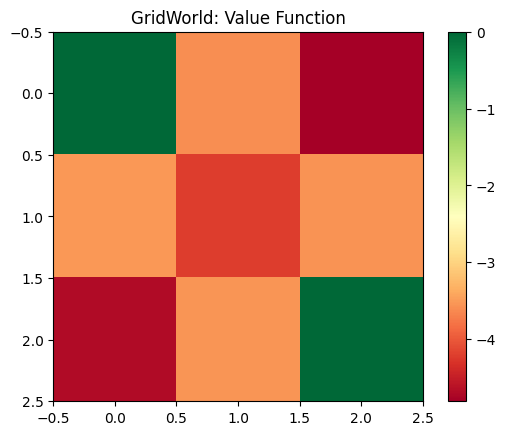

In [18]:
plot_value_function(env,V)

## TD(0) Policy Evaluation

### Algoritmo:

**Entrada:**
- Agente
- Número de episódios 𝑁  
- Taxa de aprendizado α ∈ (0, 1]  
- Environment

**Inicialização:**
- V(s) ← 0, ∀ s ∈ 𝒮

**Repetir para cada episódio (até N episódios):**  
1. Inicializar o estado s ← estado inicial do episódio  
2. Enquanto s não for terminal:  
   a. Escolher ação a ← 𝜋(s)  
   b. Executar a ação a, observar recompensa r e próximo estado s′  
   c. Atualizar:  
      V(s) ← V(s) + α × [r + γ × V(s′) − V(s)]  
   d. Atualizar o estado atual: s ← s′

**Saída:**  
- Função de valor V(s) para todos os estados sob a política 𝜋


In [19]:
def TD0_Policy_Evaluation(env,agent,alpha,N_eps):
  V = np.zeros(env.size*env.size)

  for ep in range(N_eps):
    episode = episodes(env,agent)
    T = len(episode)

    for t in range(T):
      state = episode[t].state
      idx_state = state[0]*3 + state[1]

      next_state = episode[t].next_state
      idx_next_state = next_state[0]*3 + next_state[1]

      done = episode[t].done
      reward = episode[t].reward


      if not done:
        V[idx_state] = V[idx_state] + alpha *(reward + (env.gamma*V[idx_next_state]) \
                                                             - V[idx_state])
      else:

        V[idx_state] = V[idx_state] + alpha *(reward + (env.gamma*0 - V[idx_state]))

  return V

In [20]:
V_td0 = TD0_Policy_Evaluation(env,A,alpha=0.05,N_eps=20000)

In [21]:
V_td0

array([ 0.        , -2.86407618, -4.75148258, -3.52458823, -4.21332517,
       -3.53181134, -4.59621187, -3.83970664,  0.        ])

### Visualização

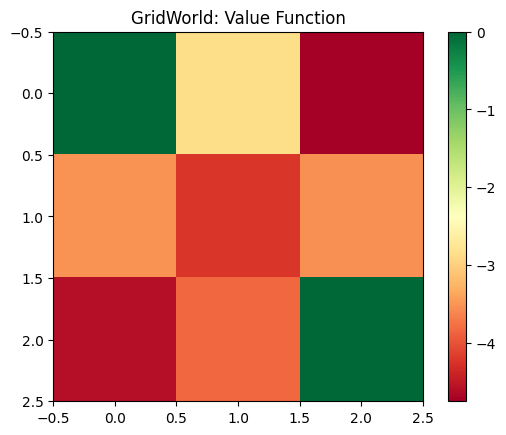

In [22]:
plot_value_function(env,V_td0)